Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# MONAI 101 tutorial

In this tutorial, we will introduce how simple it can be to run an end-to-end classification pipeline with MONAI.

These steps will be included in this tutorial, and each of them will take only a few lines of code:
- Dataset download
- Data pre-processing
- Define a DenseNet-121 and run training
- Check the results on test dataset

This tutorial will use about 7GB of GPU memory and 10 minutes to run.

## Setup imports

In [ ]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.core import parent_label, Path, accuracy
from bioMONAI.losses import CrossEntropyLossFlat
from bioMONAI.data import CategoryBlock
from bioMONAI.transforms import ScaleIntensity

from monai.config import print_config
from monai.networks.nets import DenseNet121
from monai.utils import set_determinism

from monai.apps import MedNISTDataset

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.9.1+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.24.1+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or

## Setup data directory

You can specify a directory.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
base_directory = '../../_data/'
if base_directory is not None:
    os.makedirs(base_directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if base_directory is None else base_directory
print(root_dir)

../../_data/


## Use MONAI transforms to preprocess data

Medical images require specialized methods for I/O, preprocessing, and augmentation.
They often follow specific formats, are handled with specific protocols, and the data arrays are often high-dimensional.

In this example, we will perform image loading, data format verification, and intensity scaling with three `monai.transforms` listed below, and compose a pipeline ready to be used in next steps.

## Prepare datasets using MONAI Apps

We use `MedNISTDataset` in MONAI Apps to download a dataset to the specified directory and perform the pre-processing steps in the `monai.transforms` compose.

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source. 

In [ ]:
# train_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="training", download=False).data)
# val_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="validation", download=False).data)
# test_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="test", download=False).data)

In [ ]:
from monai.transforms import LoadImageD, EnsureChannelFirstD, ScaleIntensityD, Compose

transform = Compose(
    [
        LoadImageD(keys="image", image_only=True),
        EnsureChannelFirstD(keys="image"),
        ScaleIntensityD(keys="image"),
    ]
)

In [ ]:
train_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="training", download=False)
val_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="validation", download=False)
test_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="test", download=False)

Loading dataset: 100%|██████████| 5895/5895 [00:03<00:00, 1609.31it/s]


In [ ]:
from torch.utils.data import Dataset

class FastaiWrapper(Dataset):
    def __init__(self, ds, x_keys="image", y_keys="label"):
        """
        ds: MONAI dataset (or any dict-like dataset)
        x_keys: single key (str) or list/tuple of keys for inputs
        y_keys: single key (str) or list/tuple of keys for outputs
        """
        self.ds = ds
        # Normalize to lists
        self.x_keys = [x_keys] if isinstance(x_keys, str) else list(x_keys)
        self.y_keys = [y_keys] if isinstance(y_keys, str) else list(y_keys)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        # Flatten all keys into a single tuple
        output = tuple(item[k] for k in self.x_keys + self.y_keys)
        return output

    def __getattr__(self, name):
        # Forward any unknown attribute to the underlying dataset
        return getattr(self.ds, name)

In [ ]:
train_ds2 = FastaiWrapper(train_ds)
val_ds2 = FastaiWrapper(val_ds)
test_ds2 = FastaiWrapper(test_ds)

In [ ]:
classes = ['AbdomenCT','BreastMRI','ChestCT','CXR','Hand','HeadCT']

train_ds2.vocab = classes
val_ds2.vocab = classes
test_ds2.vocab = classes

In [ ]:
from torch.utils.data import DataLoader
from fastai.data.core import DataLoaders

train_dl = DataLoader(train_ds2, batch_size=512, shuffle=True)
val_dl = DataLoader(val_ds2, batch_size=512, shuffle=False)
test_dl = DataLoader(test_ds2, batch_size=512, shuffle=False)


In [ ]:
import types
from torch.utils.data import DataLoader

def patch_fastai_compat(dl):

    def one_batch(self):
        return next(iter(self))

    def new(self, **kwargs):
        params = dict(
            dataset=self.dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
            pin_memory=self.pin_memory,
            drop_last=self.drop_last,
        )
        params.update(kwargs)

        new_dl = DataLoader(**params)

        # patch the clone too
        patch_fastai_compat(new_dl)
        return new_dl

    dl.one_batch = types.MethodType(one_batch, dl)
    dl.new = types.MethodType(new, dl)
    return dl

In [ ]:
train_dl = patch_fastai_compat(train_dl)
val_dl   = patch_fastai_compat(val_dl)

In [ ]:
dls = DataLoaders(train_dl, val_dl)

## Define a network and a supervised trainer

To train a model that can perform the classification task, we will use the DenseNet-121 which is known for its performance on the ImageNet dataset.

For a typical supervised training workflow, MONAI provides `SupervisedTrainer` to define the hyper-parameters.

In [ ]:
max_epochs = 1
device = get_device()
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=6)
loss_function = CrossEntropyLossFlat()
metrics = [accuracy]

trainer = fastTrainer(dls, model, loss_fn=loss_function, metrics=metrics, show_summary=False, lr=1e-5)

## Run the training

epoch,train_loss,valid_loss,accuracy,time
0,0.735021,0.372334,0.967430,00:12


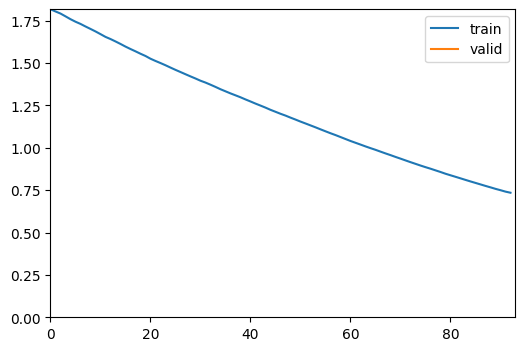

In [ ]:
trainer.fit(max_epochs)

In [ ]:
trainer.show_results()

AttributeError: 'DataLoader' object has no attribute 'show_results'

## Check the prediction on the test dataset

In [ ]:
# evaluate_classification_model(trainer, test_data, metrics=accuracy, show_graph=True);